In [4]:
import arviz as az
import matplotlib.pyplot as plt

import numpy as np
from pyro.infer import MCMC, NUTS
import torch
from pyro.infer import Predictive
import pandas as pd
import pymc as pm
import pytensor

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import scale

## Simulate Data

In [5]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

In [21]:
def create_data(c_params, n_samples, n_features, n_bias_features):
    features_obs = np.random.uniform(0, 1, size=(n_samples, n_features))
    amount = np.random.uniform(0, 2,size=(n_samples))
    logit_bias = c_params[-1] + np.matmul(features_obs[:, 0:n_bias_features], c_params[0:n_bias_features])
    logit_quant = c_params[n_bias_features]*np.multiply(features_obs[:, n_bias_features], amount) -  c_params[n_bias_features+1]*np.multiply(features_obs[:, n_bias_features + 1], amount ** 2)
    probs_obs = sigmoid(logit_bias + logit_quant)
    y_obs = np.random.binomial(1, probs_obs)
    x_obs = np.hstack((features_obs, amount.reshape(-1, 1)))
    x = torch.from_numpy(x_obs).float()
    y = torch.from_numpy(y_obs).float()

    return x, y, probs_obs


c_params = [ -4,2,3,3,1,-3 ]
n_bias_features = 3
n_features = 5
n_samples_train= 30000
n_samples_val= 2000
n_samples_test= 30000

# train
x_train, y_train, probs_obs_train = create_data(c_params, n_samples_train, n_features, n_bias_features)
x_val, y_val, probs_obs_val = create_data(c_params, n_samples_train, n_features, n_bias_features)
x_test, y_test, probs_obs_test = create_data(c_params, n_samples_test, n_features, n_bias_features)

# test
# x_obs_test = np.random.uniform(0, 1, size=(n_users, num_features))
# probs_obs_test = sigmoid(c_params[0] + np.matmul(x_obs_test, c_params[1:]))
# y_obs_test = np.random.binomial(1, probs_obs_test)



In [22]:
probs_obs_train

array([0.34130941, 0.00802656, 0.37391055, ..., 0.87891272, 0.03670484,
       0.0803966 ])

In [67]:
import pyro
import pyro.distributions as dist
from pyro.nn import PyroModule, PyroSample
import torch.nn as nn

class Torch_BNN(nn.Module):
    def __init__(self, in_dim, out_dim=1, hid_dim=10):
        super().__init__()
        self.activation = nn.Tanh()  # or nn.ReLU()
        self.layer1 = nn.Linear(in_dim, hid_dim)  # Input to hidden layer
        self.layer2 = nn.Linear(hid_dim, out_dim)  # Hidden to output layer

    def forward(self, x):
        x = self.activation(self.layer1(x))
        logits = self.layer2(x).squeeze()
        return logits

class BNN(PyroModule):
    def __init__(self, in_dim=n_features, out_dim=1, hid_dim=10, prior_scale=5.):
        super().__init__()

        self.activation = nn.Tanh()  # or nn.ReLU()
        self.layer1 = PyroModule[nn.Linear](in_dim, hid_dim)  # Input to hidden layer
        self.layer2 = PyroModule[nn.Linear](hid_dim, out_dim)  # Hidden to output layer

        # Set layer parameters as random variables
        self.layer1.weight = PyroSample(dist.Normal(0., prior_scale).expand([hid_dim, in_dim]).to_event(2))
        self.layer1.bias = PyroSample(dist.Normal(0., prior_scale).expand([hid_dim]).to_event(1))
        self.layer2.weight = PyroSample(dist.Normal(0., prior_scale).expand([out_dim, hid_dim]).to_event(2))
        self.layer2.bias = PyroSample(dist.Normal(0., prior_scale).expand([out_dim]).to_event(1))

    def forward(self, x, y=None):
        #x = x.reshape(-1, 1)
        x = self.activation(self.layer1(x))
        logits = self.layer2(x).squeeze()

        # Sampling model
        with pyro.plate("data", x.shape[0]):
            obs = pyro.sample("obs", dist.Bernoulli(logits=logits), obs=y)
        return logits

# variational inference

## Using Pyro's SVI

In [24]:
from pyro.infer import SVI, Trace_ELBO
from pyro.infer.autoguide import AutoDiagonalNormal
from tqdm.auto import trange
pyro.clear_param_store()

#model = BNN(hid_dim=10, n_hid_layers=5, prior_scale=5.)
deep_model = BNN(in_dim=n_features + 1)
mean_field_guide = AutoDiagonalNormal(deep_model)
optimizer = pyro.optim.Adam({"lr": 0.01})

svi = SVI(deep_model, mean_field_guide, optimizer, loss=Trace_ELBO())
pyro.clear_param_store()

num_epochs = 1500
progress_bar = trange(num_epochs)
loss_list = []
for epoch in progress_bar:
    loss = svi.step(x_train, y_train)

    # claculate preds for train/val data (ADD)
    loss_list.append(loss)
    progress_bar.set_postfix(loss=f"{loss / x_train.shape[0]:.3f}")

100%|██████████| 1500/1500 [00:08<00:00, 173.63it/s, loss=0.394]


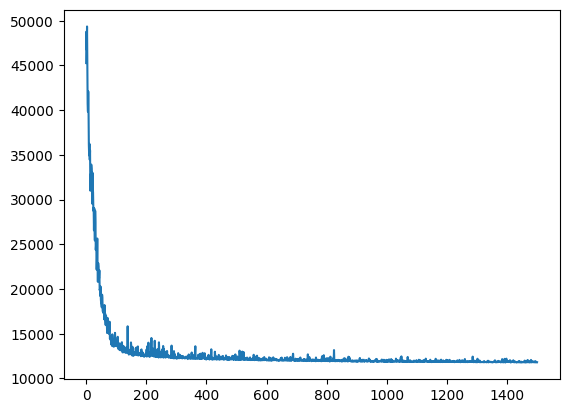

In [25]:
plt.figure()
plt.plot(loss_list)

## check parameters and logits

In [57]:
type(deep_model._modules)


dict

In [56]:
for name, attr in deep_model._modules:
    print(name, attr)

_pyro_name 
_pyro_context <pyro.nn.module._Context object at 0x7f66c4c11b80>
_pyro_params OrderedDict()
_pyro_samples OrderedDict()
training True
_parameters {}
_buffers {}
_non_persistent_buffers_set set()
_backward_pre_hooks OrderedDict()
_backward_hooks OrderedDict()
_is_full_backward_hook None
_forward_hooks OrderedDict()
_forward_hooks_with_kwargs OrderedDict()
_forward_hooks_always_called OrderedDict()
_forward_pre_hooks OrderedDict()
_forward_pre_hooks_with_kwargs OrderedDict()
_state_dict_hooks OrderedDict()
_state_dict_pre_hooks OrderedDict()
_load_state_dict_pre_hooks OrderedDict()
_load_state_dict_post_hooks OrderedDict()
_modules {'activation': Tanh(), 'layer1': PyroLinear(in_features=6, out_features=10, bias=True), 'layer2': PyroLinear(in_features=10, out_features=1, bias=True)}


In [26]:
predictive = Predictive(deep_model, guide=mean_field_guide, num_samples=1000,
                        return_sites=("layer1.weight", "layer1.bias", "obs", "_RETURN"))
samples = predictive(x_train)
logits = samples['_RETURN'].squeeze()

0.34130941218543104
tensor(0.3289)
0.00802656178854539
tensor(0.0221)
0.37391054752800035
tensor(0.3856)
0.8605328997894772
tensor(0.8506)
0.07885885844014773
tensor(0.0926)


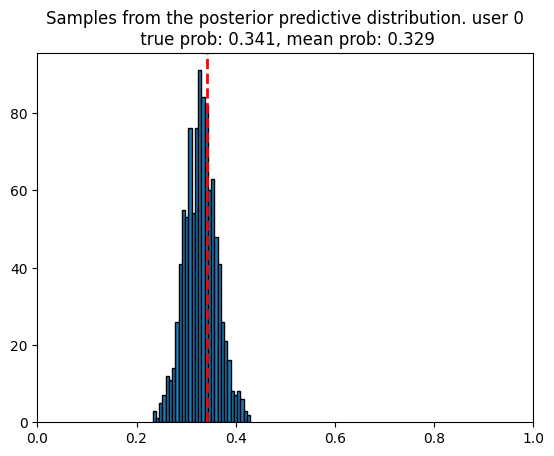

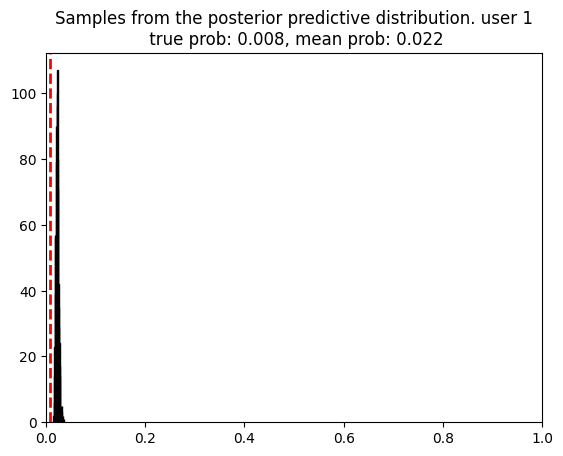

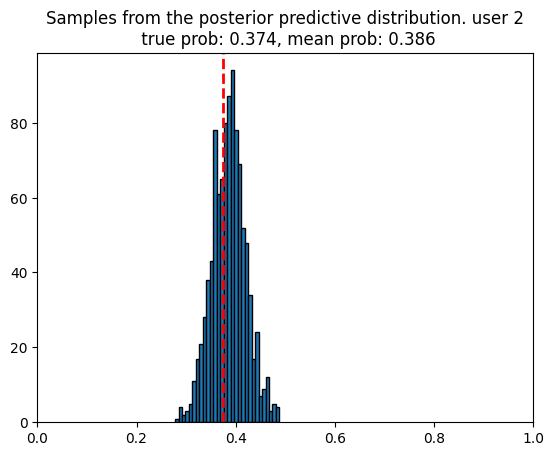

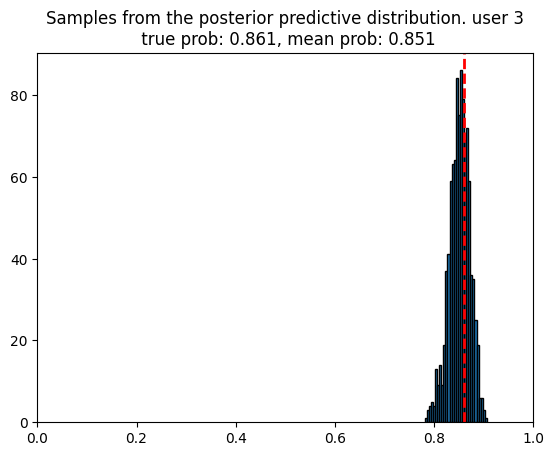

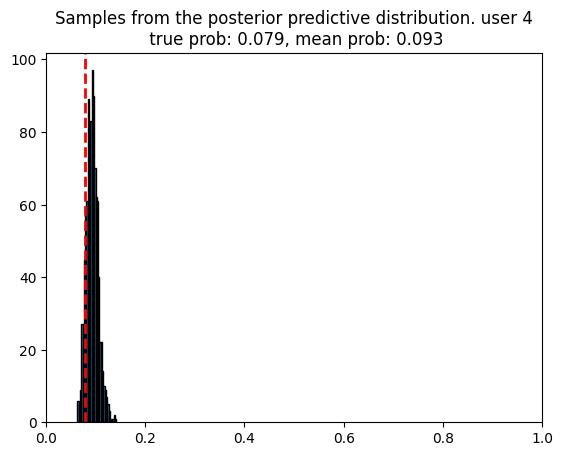

In [27]:
for ind in range(5):
    curr_pred = probs_obs_train[ind]

    preds_from_model = sigmoid(logits[:,ind])

    print(curr_pred)
    print(preds_from_model.mean())
    plt.figure()
    plt.hist(preds_from_model, bins=30, edgecolor='black')
    plt.axvline(x=curr_pred, color='r', linestyle='--', linewidth=2)
    plt.xlim(0, 1)
    plt.title(f'Samples from the posterior predictive distribution. user {ind}\n true prob: {curr_pred:.3f}, mean prob: {preds_from_model.mean():.3f}')


## check test data

In [39]:

samples_test = predictive(x_test)
logits_test = samples_test['_RETURN'].squeeze()


0.56133753746998
tensor(0.5519)
0.6822771370699698
tensor(0.5735)
0.03227819505285328
tensor(0.0504)
0.0666397640430611
tensor(0.0739)
0.19967733366551546
tensor(0.2137)
0.5987159268612572
tensor(0.7077)
0.012409242363080462
tensor(0.0238)
0.1657639263773156
tensor(0.1869)
0.1662909680035445
tensor(0.2119)
0.14392340439887888
tensor(0.1482)


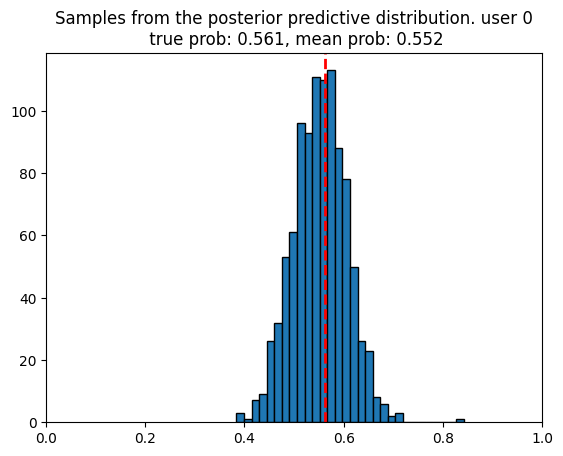

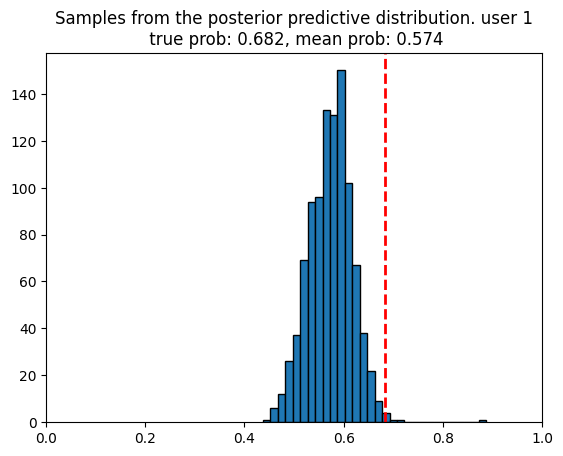

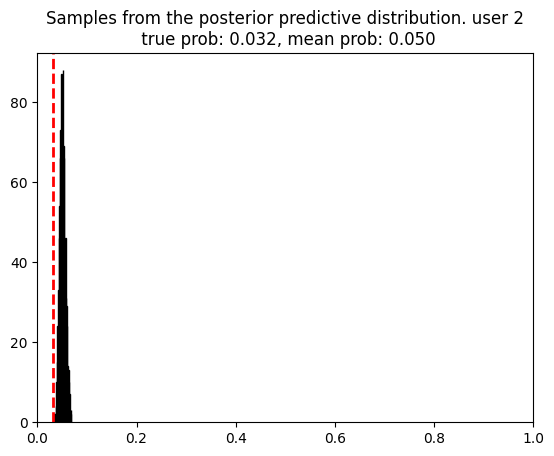

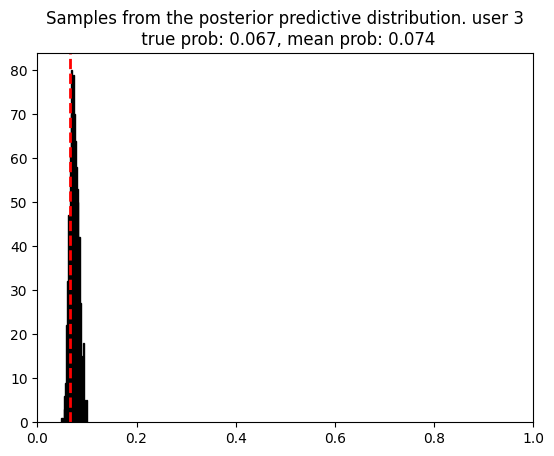

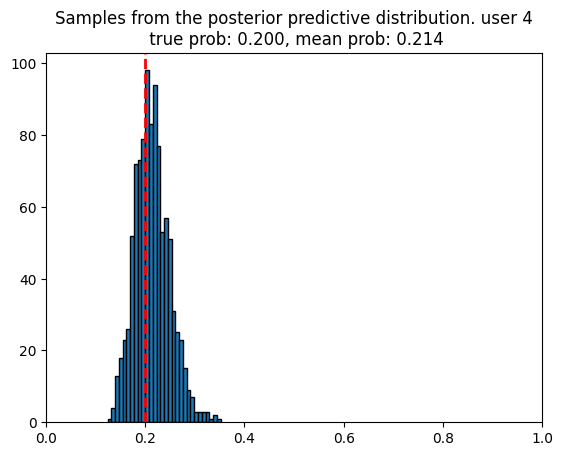

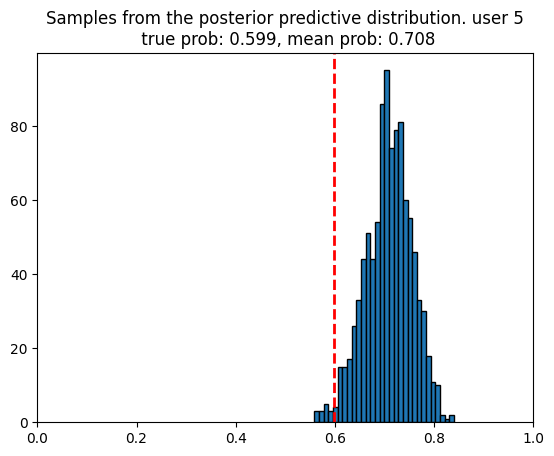

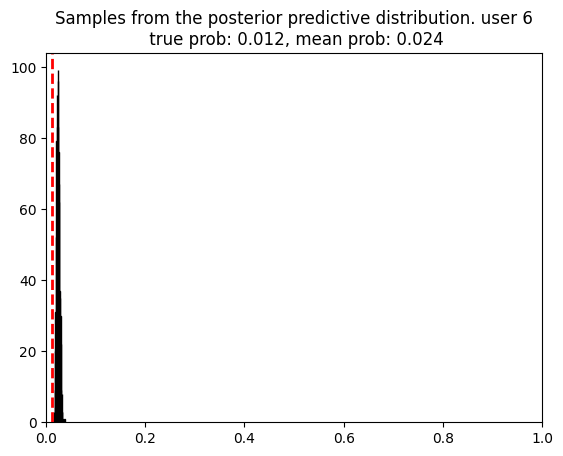

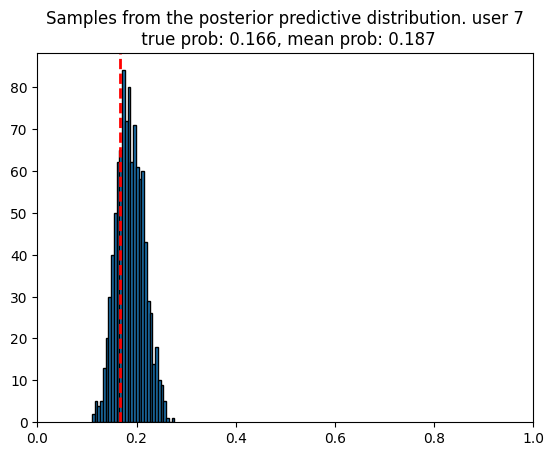

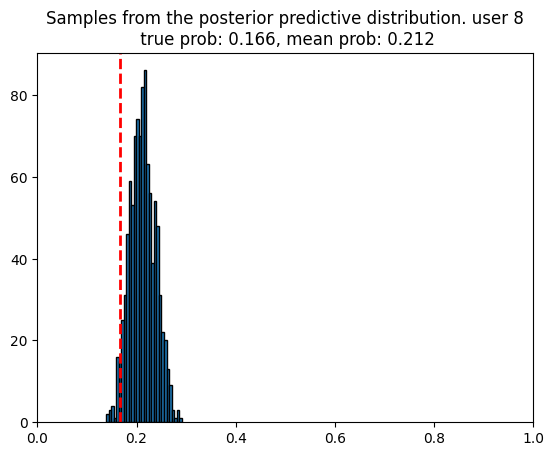

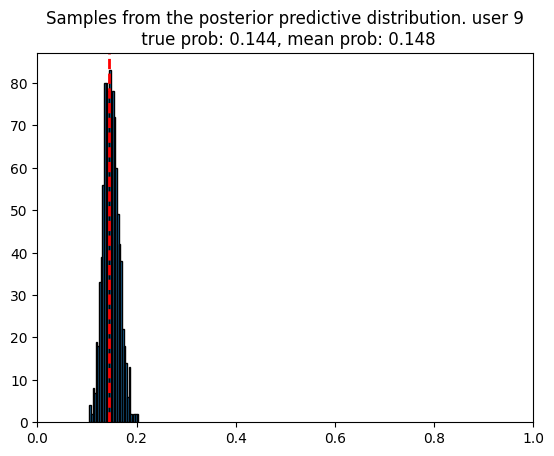

In [40]:
for ind in range(10):
    curr_pred = probs_obs_test[ind]

    preds_from_model = sigmoid(logits_test[:,ind])

    print(curr_pred)
    print(preds_from_model.mean())
    plt.figure()
    plt.hist(preds_from_model, bins=30, edgecolor='black')
    plt.axvline(x=curr_pred, color='r', linestyle='--', linewidth=2)
    plt.xlim(0, 1)
    plt.title(f'Samples from the posterior predictive distribution. user {ind}\n true prob: {curr_pred:.3f}, mean prob: {preds_from_model.mean():.3f}')


In [30]:
### Given a trained model - find optimal quantity

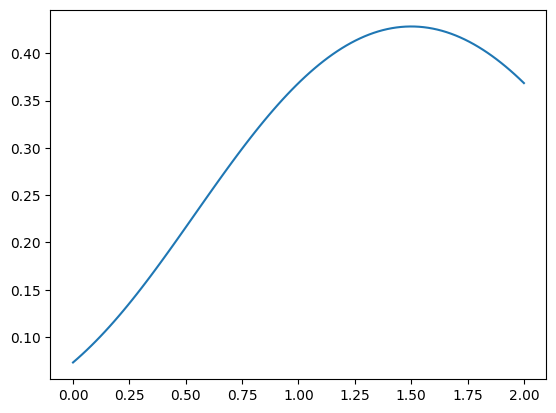

In [41]:
# first user:

ind = 0
xx = x_test[ind,:-1]
amount = np.linspace(0, 2, 100)
logit_bias = c_params[-1] + np.matmul(xx[0:n_bias_features], c_params[0:n_bias_features])
logit_quant = c_params[n_bias_features]* amount -  c_params[n_bias_features+1]* amount ** 2
probs = sigmoid(logit_bias + logit_quant)
probs
plt.figure()
plt.plot(amount, probs)


In [68]:
# regular pytorch nn:
torch_model = Torch_BNN(in_dim=n_features + 1)
#

In [71]:
# read named parameters from torch_model
model_param_names= []
for name, param in torch_model.named_parameters():
    model_param_names.append(name)



In [72]:
model_param_names


['layer1.weight', 'layer1.bias', 'layer2.weight', 'layer2.bias']

In [74]:
# just get a sample of the model parameters
predictive = Predictive(deep_model, guide=mean_field_guide, num_samples=1,
                        return_sites= tuple(model_param_names) + ("obs", "_RETURN"))
dummy_sample = predictive(torch.zeros(1, n_features + 1))

In [106]:
# Load sampled parameters to torch_model and freeze them
for name, param in torch_model.named_parameters():
    param.data = dummy_sample[name].squeeze()
    param.requires_grad_(False)
    print(f"Parameter name: {name}")


Parameter name: layer1.weight
Parameter name: layer1.bias
Parameter name: layer2.weight
Parameter name: layer2.bias


In [75]:
dummy_sample.keys()


dict_keys(['layer1.weight', 'layer1.bias', 'layer2.weight', 'layer2.bias', 'obs', '_RETURN'])

In [88]:
dummy_sample['layer1.weight']

False

In [97]:
torch_model.layer1.weight

Parameter containing:
tensor([[-0.6545, -0.1899,  0.2772,  2.2113, -0.3991,  1.0734],
        [ 1.2846,  0.0337, -0.8601, -1.5393,  1.7850,  1.2487],
        [ 1.7623,  0.7088,  1.6112,  2.2470,  2.0050, -0.3188],
        [-1.5499,  1.1856,  1.2599,  0.6728, -0.4065,  0.2680],
        [-1.2984,  0.9096,  1.5723, -1.7887, -0.9179,  1.8998],
        [ 0.2520,  0.6049, -3.5489, -1.4331, -0.8207, -3.1173],
        [ 0.8020,  1.2804,  0.5340, -1.3656, -3.8617,  1.8908],
        [-2.7462, -0.7485,  0.4954,  0.5847, -2.7944,  0.8523],
        [ 0.6117, -1.2293, -1.2567, -2.2157,  1.2937,  1.2842],
        [ 1.1377,  0.9493,  2.9940,  4.4738, -1.4734,  1.2883]],
       requires_grad=True)

In [99]:
# Let's say we want to preprocess some saved weights and use
# the result as new weights.
saved_weights = [0.1, 0.2, 0.3, 0.25]
weights = torch.tensor(saved_weights)
weights

tensor([0.1000, 0.2000, 0.3000, 0.2500])

In [103]:
weights

tensor([0.1000, 0.2000, 0.3000, 0.2500])

In [102]:

# Now, start to record operations done to weights
weights.requires_grad_(False)
out = weights.pow(2).sum()
out.backward()
weights.grad

RuntimeError: element 0 of tensors does not require grad and does not have a grad_fn

In [92]:
torch_model.state_dict()

OrderedDict([('layer1.weight',
              tensor([[-0.6545, -0.1899,  0.2772,  2.2113, -0.3991,  1.0734],
                      [ 1.2846,  0.0337, -0.8601, -1.5393,  1.7850,  1.2487],
                      [ 1.7623,  0.7088,  1.6112,  2.2470,  2.0050, -0.3188],
                      [-1.5499,  1.1856,  1.2599,  0.6728, -0.4065,  0.2680],
                      [-1.2984,  0.9096,  1.5723, -1.7887, -0.9179,  1.8998],
                      [ 0.2520,  0.6049, -3.5489, -1.4331, -0.8207, -3.1173],
                      [ 0.8020,  1.2804,  0.5340, -1.3656, -3.8617,  1.8908],
                      [-2.7462, -0.7485,  0.4954,  0.5847, -2.7944,  0.8523],
                      [ 0.6117, -1.2293, -1.2567, -2.2157,  1.2937,  1.2842],
                      [ 1.1377,  0.9493,  2.9940,  4.4738, -1.4734,  1.2883]])),
             ('layer1.bias',
              tensor([-2.7804, -2.6768,  1.7649, -1.3594,  0.2453, -0.0113,  0.9448, -2.8854,
                      -0.8464,  2.8107])),
             ('layer

## Simple BNN

In [66]:
import pyro
import pyro.distributions as dist
from pyro.nn import PyroModule, PyroSample
import torch.nn as nn


class Simple_BNN(PyroModule):
    def __init__(self, in_dim=num_features, out_dim=1, hid_dim=10, prior_scale=5.):
        super().__init__()

        self.layer1 = PyroModule[nn.Linear](in_dim, out_dim)

        # Set layer parameters as random variables
        self.layer1.weight = PyroSample(dist.Normal(0., prior_scale).expand([out_dim, in_dim, ]).to_event(2))
        self.layer1.bias = PyroSample(dist.Normal(0., prior_scale).expand([out_dim]).to_event(1))


    def forward(self, x, y=None):
        #x = x.reshape(-1, 1)
        logits = self.layer1(x).squeeze()

        # Sampling model
        with pyro.plate("data", x.shape[0]):
            obs = pyro.sample("obs", dist.Bernoulli(logits=logits), obs=y)
        return logits

In [68]:
from pyro.infer import SVI, Trace_ELBO
from pyro.infer.autoguide import AutoDiagonalNormal
from tqdm.auto import trange
pyro.clear_param_store()

#model = BNN(hid_dim=10, n_hid_layers=5, prior_scale=5.)
model = Simple_BNN(in_dim=num_features)
mean_field_guide = AutoDiagonalNormal(model)
optimizer = pyro.optim.Adam({"lr": 0.01})

svi = SVI(model, mean_field_guide, optimizer, loss=Trace_ELBO())
pyro.clear_param_store()

num_epochs = 10000
progress_bar = trange(num_epochs)
loss_list = []
for epoch in progress_bar:
    loss = svi.step(x_train, y_train)
    loss_list.append(loss)
    progress_bar.set_postfix(loss=f"{loss / x_train.shape[0]:.3f}")

100%|██████████| 10000/10000 [01:26<00:00, 116.12it/s, loss=0.375]


## check parameters

In [81]:
predictive = Predictive(model, guide=mean_field_guide, num_samples=1000,
                        return_sites=("layer1.weight","layer1.bias",  "obs", "_RETURN"))
samples = predictive(x_train)

In [85]:
samples['layer1.weight'].squeeze()

tensor([[-5.1278,  2.0692,  2.7831],
        [-4.9906,  2.1065,  2.7627],
        [-4.9230,  2.0463,  2.7396],
        ...,
        [-5.0156,  2.1743,  2.7812],
        [-5.0338,  2.0542,  2.8160],
        [-5.0444,  2.0242,  2.7726]])

In [78]:
mean_field_guide.get_posterior().mean

Parameter containing:
tensor([-5.0106,  2.0551,  2.7915, -1.8419], requires_grad=True)

In [79]:
mean_field_guide.get_posterior().stddev

tensor([0.0657, 0.0463, 0.0439, 0.0283], grad_fn=<SqrtBackward0>)

In [ ]:
for name, param in model.named_parameters():
    print(f"Parameter name: {name}")
    print(param)